<a href="https://colab.research.google.com/github/aditya301cs/100-days-of-machine-learning/blob/main/Linear_Regression_Assumptions_Synthetic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Assumptions – Practical Validation

This notebook explains and validates the **assumptions of Linear Regression**
using visual and statistical techniques.

Understanding these assumptions is critical for:
- Model correctness
- Interview discussions
- Real-world deployment decisions


## Why Do Linear Regression Assumptions Matter?

In interviews, a common question is:

❝ When should we NOT use Linear Regression? ❞

Linear Regression works correctly **only when certain assumptions are satisfied**.
If these assumptions are violated:
- Coefficients become unreliable
- Predictions become misleading
- Statistical inference breaks down


## 1. Import Required Libraries

We import libraries for:
- Data manipulation
- Statistical testing
- Visualization
- Regression diagnostics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import shapiro


## 2. Load the Dataset

The dataset (`data.csv`) contains:
- feature1, feature2, feature3 → Independent variables
- target → Continuous dependent variable

This represents a **multiple linear regression** scenario.


In [2]:
df = pd.read_csv('data.csv')

In [ ]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


## 3. Dataset Overview

Before modeling, interviewers expect you to:
- Verify dataset size
- Check data types
- Ensure no missing values


In [3]:
df.shape


(200, 4)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   feature1  200 non-null    float64
 1   feature2  200 non-null    float64
 2   feature3  200 non-null    float64
 3   target    200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## 4. Statistical Summary

Descriptive statistics help us understand:
- Feature scale
- Mean and variance
- Presence of extreme values


In [5]:
df.describe()


,feature1,feature2,feature3,target
count,200.000000,200.000000,200.000000,200.000000
mean,0.019595,-0.045539,0.048697,4.323508
std,1.041478,1.057713,0.974019,97.258970
min,-2.915738,-2.983970,-2.272244,-257.063427
25%,-0.647775,-0.810995,-0.650268,-60.735485
50%,0.007320,0.013617,-0.078591,2.991268
75%,0.704479,0.680593,0.729907,76.404521
max,3.314304,2.676112,2.811878,290.546161


## 5. Separate Features and Target

In regression problems:
- X → Matrix of independent variables
- y → Target variable

This separation is mandatory before model training.


In [6]:
X = df[['feature1', 'feature2', 'feature3']]
y = df['target']


In [ ]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

## 6. Train-Test Split (Interview Perspective)

We split the dataset to:
- Train the model on known data
- Test assumptions on unseen data

This prevents overfitting and validates generalization.


In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

## 7. Train the Linear Regression Model

At this stage, the model:
- Learns regression coefficients for each feature
- Minimizes the sum of squared residuals (OLS)


In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

## 8. Model Coefficients Interpretation

Each coefficient represents:
- The change in target value
- For a one-unit change in that feature
- Keeping other features constant


In [11]:
pd.Series(lr.coef_, index=X.columns)


,0
feature1,72.748777
feature2,-0.277188
feature3,53.338616


## 9. Generate Predictions

Predictions are required to:
- Evaluate performance
- Compute residuals
- Validate assumptions


In [12]:
y_pred = lr.predict(X_test)


## 10. Residuals

Residuals represent model error:

Residual = Actual Value − Predicted Value

All linear regression assumptions are validated using residuals.


In [13]:
# Residual
y_pred = lr.predict(X_test)
residual = y_test - y_pred

## Assumption 1: Linearity

**Interview Definition:**
The relationship between predictors and target should be linear.

**Check:**
Actual vs Predicted values should follow a straight-line pattern.


## 1. Linear Relationship

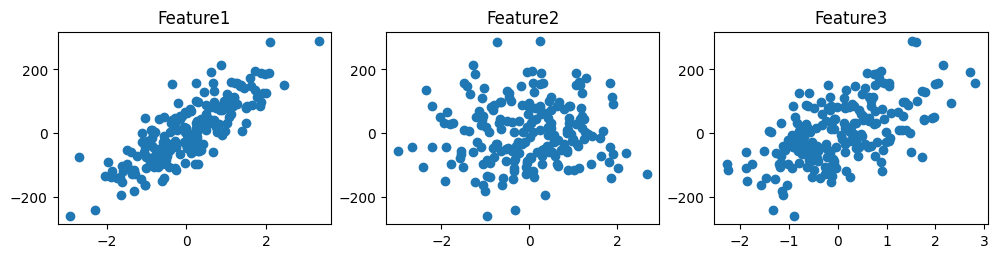

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

## 2. Homoscedasticity

## Assumption 2: Homoscedasticity

Residuals should have:
- Constant variance
- No funnel or cone-shaped pattern

Violation leads to unreliable confidence intervals.


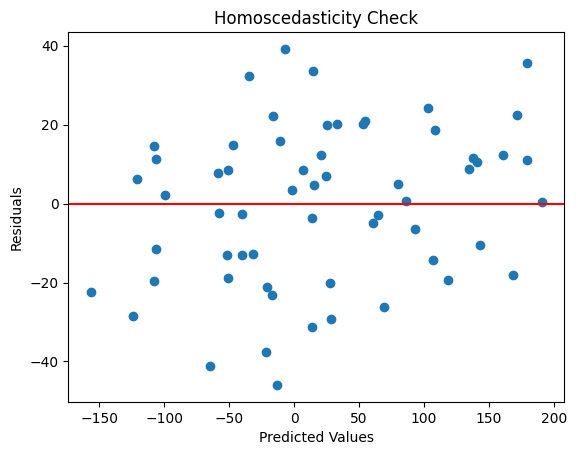

In [16]:
plt.scatter(y_pred, residual)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.show()


## 3. Normality of Residual

## Assumption 3: Normality of Residuals

Residuals should follow a normal distribution.
This is required for:
- Hypothesis testing
- Valid p-values


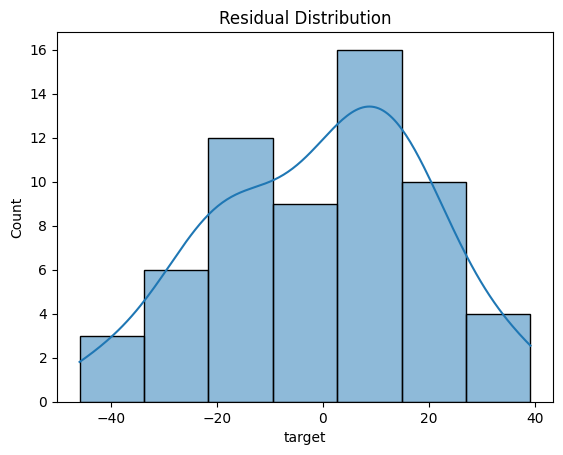

In [18]:
sns.histplot(residual, kde=True)
plt.title("Residual Distribution")
plt.show()


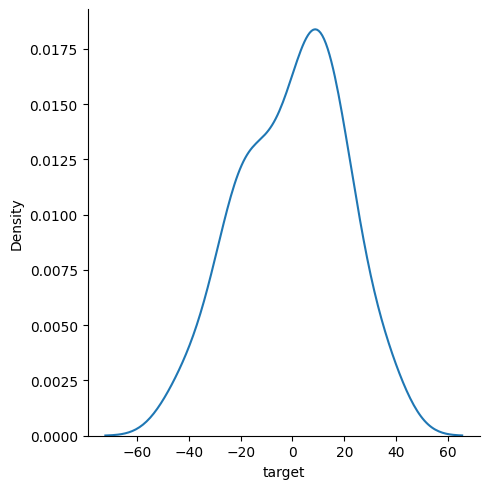

In [24]:
sns.displot(residual,kind='kde')

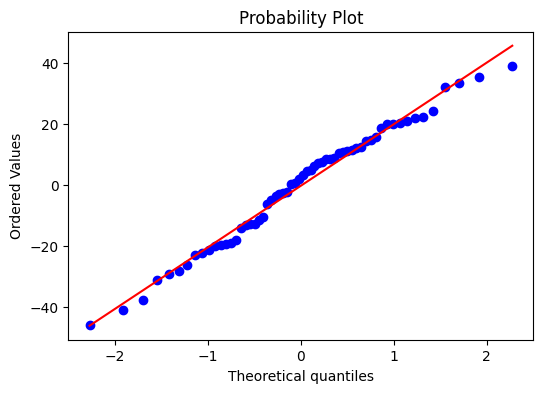

In [25]:
# QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

## Shapiro-Wilk Test (Normality Test)

- H₀: Residuals are normally distributed
- p-value > 0.05 → Normality assumed


In [20]:
stat, p = shapiro(residual)
print("Shapiro-Wilk p-value:", p)


Shapiro-Wilk p-value: 0.5057619305631462


## Autocorrelation of Residuals

## Assumption 4: Independence of Errors

Residuals should not show patterns when plotted sequentially.
This assumption is critical in time-dependent data.


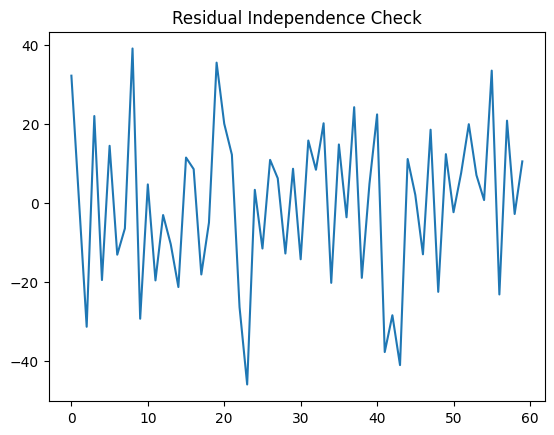

In [22]:
plt.plot(residual.values)
plt.title("Residual Independence Check")
plt.show()


## Assumption 5: No Multicollinearity

In multiple linear regression:
- Independent variables should not be highly correlated
- High correlation inflates coefficient variance


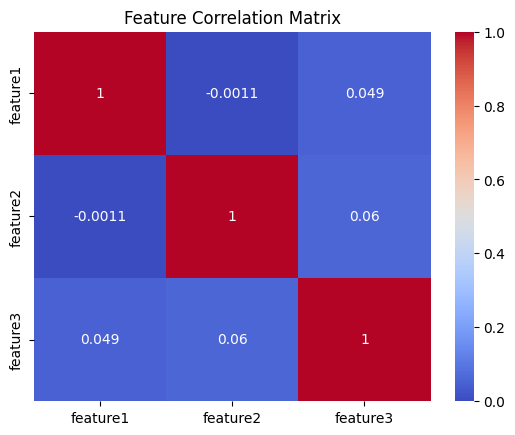

In [23]:
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


## Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [ ]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<AxesSubplot:>

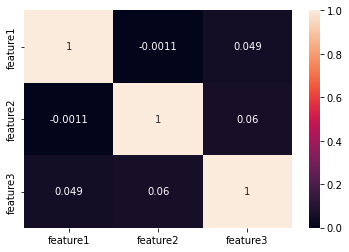

In [ ]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## Final Interview Summary

✔ Linearity: Relationship appears linear  
✔ Homoscedasticity: Residual variance is stable  
✔ Normality: Residuals approximately normal  
✔ Independence: No visible pattern in residuals  
✔ Multicollinearity: Features not strongly correlated  

Conclusion: Linear Regression is appropriate for this dataset.


## Conclusion

This notebook demonstrates **interview-ready validation**
of linear regression assumptions using a synthetic dataset.

Key takeaway for interviews:
> "I don't just train models — I validate whether they are valid."
